<a href="https://colab.research.google.com/github/Viishnu07/DLI_GroupAE_URLPhishing/blob/main/Viishnu_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Basic setup
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
# For visualization and cleaning insights
import matplotlib.pyplot as plt
import seaborn as sns

Data Cleaning Process


1. Upload Datasets
2. Removing duplicated rows and removing the column where all values are 0
3. Removing missing values by removing columns with more than 50% of missing values handle missing values
4. Seperate the features and target and normalize the features




In [ ]:
# Upload Datasets
# Load the dataset from GitHub raw link
url = "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/mendeley_dataset_full.csv"
df = pd.read_csv(url)

# Read CSV
print("Shape:", df.shape)
df.head()

Shape: (88647, 112)


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


2. Removing any duplicated rows and removing columns where the value is only 0

In [ ]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Remove single-valued columns
single_val_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=single_val_cols, inplace=True)

3. -1 has been acknowledge as the missing value and replcace it with NaN and removing the column that has more than 50% NaN and replace fill the remaining NaN by using the means of the column

In [ ]:
# Replace -1 with NaN (treat as missing values)
df.replace(-1, np.nan, inplace=True)

# Drop columns where too much data is missing (e.g., > 50%)
missing_ratio = df.isna().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.5].index
print("Dropping columns with > 50% missing values:", list(cols_to_drop))
df.drop(columns=cols_to_drop, inplace=True)

# Fill remaining NaNs with column mean (or median if skewed)
df.fillna(df.mean(numeric_only=True), inplace=True)

Dropping columns with > 50% missing values: ['qty_dot_directory', 'qty_hyphen_directory', 'qty_underline_directory', 'qty_slash_directory', 'qty_questionmark_directory', 'qty_equal_directory', 'qty_at_directory', 'qty_and_directory', 'qty_exclamation_directory', 'qty_space_directory', 'qty_tilde_directory', 'qty_comma_directory', 'qty_plus_directory', 'qty_asterisk_directory', 'qty_hashtag_directory', 'qty_dollar_directory', 'qty_percent_directory', 'directory_length', 'qty_dot_file', 'qty_hyphen_file', 'qty_underline_file', 'qty_slash_file', 'qty_questionmark_file', 'qty_equal_file', 'qty_at_file', 'qty_and_file', 'qty_exclamation_file', 'qty_space_file', 'qty_tilde_file', 'qty_comma_file', 'qty_plus_file', 'qty_asterisk_file', 'qty_hashtag_file', 'qty_dollar_file', 'qty_percent_file', 'file_length', 'qty_dot_params', 'qty_hyphen_params', 'qty_underline_params', 'qty_slash_params', 'qty_questionmark_params', 'qty_equal_params', 'qty_at_params', 'qty_and_params', 'qty_exclamation_param

4. Specifie the target and seperate from other features and normalize the features

In [ ]:
# Separate features and label
X = df.drop(columns=['phishing'])
y = df['phishing']

# Normalize features for ML models (especially DNN/MLP)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Select Top 30 features using SelectKBest

In [ ]:
# Apply SelectKBest with ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=30)  # Choose top 30 features
X_kbest = selector.fit_transform(X_scaled, y)

# Get selected feature names
mask = selector.get_support()  # boolean mask
selected_features_kbest = X.columns[mask]

# See scores
scores = selector.scores_
feature_scores = pd.DataFrame({'Feature': X.columns, 'F-score': scores})
top30 = feature_scores[mask].sort_values(by='F-score', ascending=False)

print("Top 30 features (by F-Score):")
print(top30.reset_index(drop=True))

Top 30 features (by F-Score):
                   Feature       F-score
0            qty_slash_url  82365.724733
1   time_domain_activation  27149.330024
2               length_url  21725.606202
3           qty_dot_domain   6600.758686
4            qty_equal_url   6322.637544
5              qty_tld_url   4179.661455
6           qty_hyphen_url   3568.245076
7              qty_and_url   3286.967573
8        qty_underline_url   3281.248283
9             email_in_url   3164.847375
10             qty_dot_url   2574.830183
11              domain_spf   1600.404141
12  time_domain_expiration   1579.474014
13       qty_hyphen_domain   1222.694620
14           qty_redirects   1172.517563
15       qty_vowels_domain   1056.462388
16    qty_questionmark_url   1038.233670
17              qty_at_url   1032.424473
18           url_shortened    866.304119
19          qty_mx_servers    682.727360
20                  asn_ip    579.324218
21         qty_ip_resolved    532.359651
22         qty_nameservers 

Select Top 30 Features using Random Forest Feature Importance

In [ ]:
# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Get feature importances
importances = rf.feature_importances_

# Create a sorted DataFrame of features and importances
rf_feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select top 30 features
top30_rf = rf_feature_scores.head(30)
print("🌲 Top 30 features by Random Forest:")
print(top30_rf.reset_index(drop=True))

🌲 Top 30 features by Random Forest:
                   Feature  Importance
0            qty_slash_url    0.277432
1               length_url    0.220892
2   time_domain_activation    0.114689
3           qty_dot_domain    0.047495
4           qty_hyphen_url    0.030842
5                   asn_ip    0.030733
6             ttl_hostname    0.030426
7            domain_length    0.029401
8            time_response    0.029258
9   time_domain_expiration    0.023597
10             qty_dot_url    0.020219
11       qty_vowels_domain    0.019385
12           qty_equal_url    0.018859
13          qty_mx_servers    0.014913
14         qty_nameservers    0.014684
15         qty_ip_resolved    0.010180
16           qty_redirects    0.010097
17       qty_underline_url    0.009653
18              domain_spf    0.009024
19             qty_and_url    0.008801
20             qty_tld_url    0.007997
21     tls_ssl_certificate    0.007157
22       qty_hyphen_domain    0.004098
23           url_shortened  

Comparing Both Features Top 30

In [ ]:
# Get just feature names from both
kbest_set = set(top30['Feature'])
rf_set = set(top30_rf['Feature'])

# Overlap
common_features = kbest_set & rf_set
only_in_kbest = kbest_set - rf_set
only_in_rf = rf_set - kbest_set

print(f"Common features (both methods): {len(common_features)}")
print("Shared:", list(common_features))
print("Only in SelectKBest:", list(only_in_kbest))
print("Only in Random Forest:", list(only_in_rf))


Common features (both methods): 26
Shared: ['qty_and_url', 'email_in_url', 'qty_percent_url', 'qty_hyphen_domain', 'qty_equal_url', 'qty_vowels_domain', 'domain_spf', 'qty_dot_domain', 'qty_nameservers', 'qty_underline_url', 'qty_ip_resolved', 'qty_slash_url', 'qty_mx_servers', 'length_url', 'time_domain_activation', 'qty_tld_url', 'url_shortened', 'qty_redirects', 'qty_at_url', 'asn_ip', 'time_domain_expiration', 'tls_ssl_certificate', 'qty_dot_url', 'qty_questionmark_url', 'domain_in_ip', 'qty_hyphen_url']
Only in SelectKBest: ['qty_exclamation_url', 'qty_tilde_url', 'url_google_index', 'qty_dollar_url']
Only in Random Forest: ['ttl_hostname', 'qty_plus_url', 'time_response', 'domain_length']


Select the shared top features from both SelectKbest and Random Forest

In [ ]:
# Create a new DataFrame from the scaled feature set using only the shared features
X_shared = pd.DataFrame(X_scaled, columns=X.columns)[list(common_features)]

# X_shared: features to use in your model
# y: target labels (already defined earlier)

print("Final dataset shape:", X_shared.shape)


Final dataset shape: (87209, 26)


MLP Model (Keras)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7742 - loss: 0.4513 - val_accuracy: 0.9108 - val_loss: 0.2156
Epoch 2/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9048 - loss: 0.2285 - val_accuracy: 0.9154 - val_loss: 0.1986
Epoch 3/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9101 - loss: 0.2121 - val_accuracy: 0.9188 - val_loss: 0.1876
Epoch 4/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9143 - loss: 0.1986 - val_accuracy: 0.9220 - val_loss: 0.1786
Epoch 5/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9166 - loss: 0.1887 - val_accuracy: 0.9236 - val_loss: 0.1734
Epoch 6/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9207 - loss: 0.1803 - val_accuracy: 0.9280 - val_loss: 0.1666
Epoch 7/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9236 - loss: 0.1755 - val_accuracy: 0.9318 - val_loss: 0.1616
Epoch 8/10
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9264 - loss: 0.1738 - val_accuracy: 0.9323 - val_

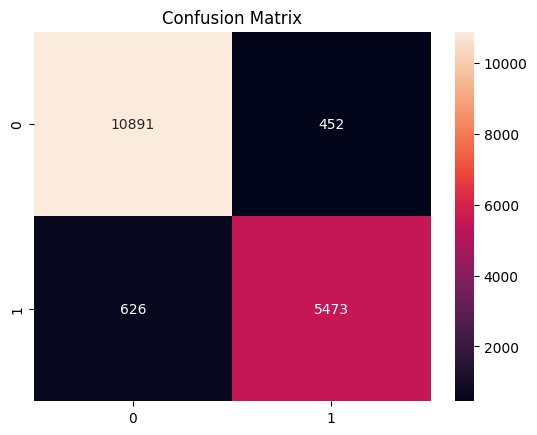

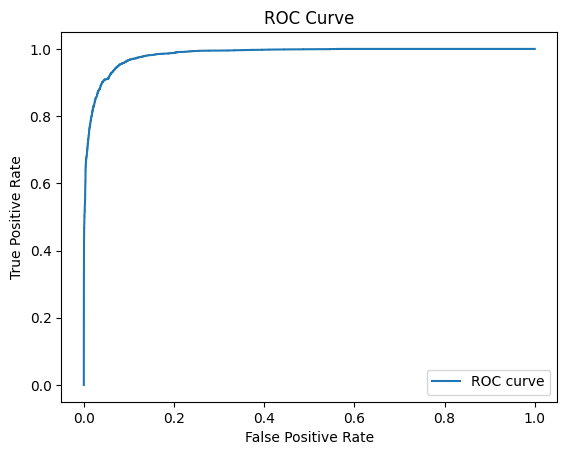

Achieved F1 = 0.91, target met


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # Changed from StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load Data - Removed as data is already loaded and processed
# df = pd.read_csv('cleaned_dataset.csv')
# X = df.drop('phishing', axis=1)
# y = df['phishing']

# Use the already prepared X_shared and y
X = X_shared # Use the shared features DataFrame
# y is already defined

# Convert to NumPy arrays before splitting
X = X.to_numpy()
y = y.to_numpy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Scale - Removed as data is already scaled
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# Build MLP
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# Evaluate
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label='ROC curve')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Verdict
f1 = float(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'])
print(f"Achieved F1 = {f1:.2f}, target {'met' if f1 >= 0.9 else 'not met'}")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Save model - Changed the save path to model.h5 (standard Keras format)
model.save('/content/drive/My Drive/Colab Notebooks/mlp_phishing_model.h5')